# <span style="color:darkblue"> Assignment 3: Exploring the rise of artificial intelligence scholarship through OpenAlex </span>

<font size = "5">
Name: Tanya Jagdish

## <span style="color:darkblue"> Section A: Introduction

Artificial intelligence and its use in the world has increased incredibly in recent years.

This assignment explores the rise of academic publications in artificial intelligence using OpenAlex, a open-source catalog
of global research system, with millions of records from different types of sources. 

This assignment answers the following key 3 questions in the subsequent sections of this report:
1. How many scholarly work have 'artificial intelligence' in the title?

2. What are some more recent trends (i.e., after 2020) in scholarship on artificial intelligence? Specifically:

    (a) Where are the authors producing these works located in?
    
    (b) What are the most cited work on this topic and where are they from?

3. How have the number of scholarly work on artificial intelligence and other similar types of work, including LLMs, deep learning, GPT 
    changed since the beginning of the 21st century?

The next three sections are subsequently divided into answering these questions

## <span style="color:darkblue"> Section B: Analysis

### <span style="color:darkblue"> Import libraries

In [10]:
import pandas as pd             # Handles dataframes
import matplotlib.pyplot as plt # For plotting graphs
import requests                 # Requests data from an API
import json                     # Handles JSON object
import jmespath                 # Allows you to moreeasily navigate JSON objects

### <span style="color:darkblue"> Q1. How many scholarly work have 'artificial intelligence' in the title?

All three questions follow a similar workflow in extracting data using OpenAlex API.

The workflow is as follows:

* Define url + parameters/filters for extracting data
* Use OpenAlex API to extract search results
* Save as JSON file/dataframe as needed for further analysis

To answer the first question: How many publications have 'artificial intelligence' in the title, I use a similar workflow and basic functions to calculate this number

In [30]:
# define base url used across all three questions
url = "https://api.openalex.org/works" 

#define parameters for filter for q1
params_q1 = {
    "filter": 'title.search:"artificial intelligence"'
}

#search for 'artificial intelligence' works
q1_search = requests.get(url, params=params_q1)

#parse JSON response
q1_data = q1_search.json()

#save response JSON
with open('json_files/ai_search_results.json', 'w', encoding='utf-8') as file:
    json.dump(q1_data, file, indent=4)
    
#get number of total scholarly work
num_sources = q1_data['meta']['count']
print(f"There are {num_sources:,} number of scholarly work with 'artificial intelligence' in the title")

There are 196,794 number of scholarly work with 'artificial intelligence' in the title


### <span style="color:darkblue"> Q2. What are some more recent trends in scholarship on artificial intelligence?

In the second question, the analysis only focuses on publications published after January 1, 2020 to analyze recent trends.

This section is separated into two parts:

(a) What countries are the authors publishing work on AI located in?

(b) What are the top 10 cited papers in AI and what are some of its characteristics?

#### **Part (a): What countries are the authors publishing work on AI located in? (since 2020)**

Note: 

* If the same publication has more than one author and each author is from a different country, then the publication is counted towards each author's affiliated country

* This is a function of how 'group_by' works within OpenAlex's API

* Publications with no country data affiliated with its authors don't appear in any bucket

* Here I am using countries that the author is affiliated with as a grouping mechanism since that is what the assignment asks us to do

* One can also use 'instuitions.country_code', i.e., the country that the author's institute is affiliated with, which may lead to different results

<b> Define url + parameters

In [219]:
#define parameters for filter for q2_a
params_q2_a = {
    #filters for AI in title and work after Jan 1 2020
  "filter": 'title.search:"artificial intelligence",from_publication_date:2020-01-01',

  #groups work by countries of authors; note it includes all authors
  "group_by": "authorships.countries",  

  #sorts by number of work per country, descending
  "sort": "count:desc",
  
  "per_page": 200
}


<b> Use API to extract info

In [ ]:
#call the API
q2_a_search = requests.get(url, params=params_q2_a)
q2_a_data = q2_a_search.json()

# print metadata count
num_ai_sources_2020 = q2_a_data['meta']['count']
print(f"There are {num_ai_sources_2020:,} number of works with 'artificial intelligence' in the title since 2020")


<b> Save dataframe + visualize results

In [218]:
#save response JSON
with open('json_files/q2_a.json', 'w', encoding='utf-8') as file:
    json.dump(q2_a_data, file, indent=4)

#create a dataframe to store number of publications per country
country_publications_df = (pd.DataFrame(q2_a_data['group_by'])
                           .rename(columns={"key_display_name":"Country", "count": "n_works" })) #rename to appr column names

country_publications_df["No. of publications on AI since 2020"] = country_publications_df["n_works"].apply(lambda x: f"{int(x):,}" if pd.notna(x) else "")

country_publications_df_pretty = country_publications_df[["Country", "No. of publications on AI since 2020"]] #make pretty columns

#display top 10 countries
country_publications_df_pretty.head(10).style


,Country,No. of publications on AI since 2020
0,United States of America,"20,901"
1,China,"16,921"
2,India,"12,699"
3,United Kingdom of Great Britain and Northern Ireland,"7,027"
4,Italy,"4,247"
5,Germany,"4,155"
6,Canada,"3,555"
7,Australia,"3,042"
8,Spain,"2,960"
9,Turkey,"2,948"


<font size = 4> 
<b> Analysis comments </b>

<font size = 3>

* US, China, India produce the most amount of scholarly work on AI, especially since 2020

* From 2020 onwards, there have been 163,447 works with AI in the title. This is ~80% of all scholarly work on AI that exists in OpenAlex

* This tells us that there has been a boom in AI research especially since 2020

#### **Part (b): What are the names of 10 most highly cited papers on AI since 2020?**

To pull out information on the top 10 most highly cited papers on AI since 2020, I'll use the three step method described above

<i><b> 

Define url+parameters and extract data using API </i>

In [89]:
#define parameters for filter for question q2_b
params_q2_b = {
  #filter for AI in title, publication after 2020
  "filter": 'title.search:"artificial intelligence",from_publication_date:2020-01-01',

  #sort by number of times the paper is cited
  "sort": "cited_by_count:desc",
  
  #limit to ten ID per page
  #doing this since we only want top 10 cited papers
  "per_page": 10,

  #only keeping certain information needed in this analysis
  "select": "id, display_name, publication_year, cited_by_count, authorships"
}

#call the API
q2_b_search = requests.get(url, params=params_q2_b)
q2_b_data = q2_b_search.json()

#save response JSON
with open('json_files/q2_b.json', 'w', encoding='utf-8') as file:
    json.dump(q2_b_data, file, indent=4)

<i><b> Save dataframe + visualize results </i>

In [93]:
# Helper functions to extract nested fields within authorship safely

#extracts names
def get_author_names(authorships):
    #return a list of author display names in order
    #handles missing or null structures
    names = []
    for au in (authorships or []):
        name = (au.get("author") or {}).get("display_name")
        if name:
            names.append(name)
    return names

#extract instituitions of authors
def get_institution_names(authorships):
    insts = set()
    for au in (authorships or []):
        for inst in (au.get("institutions") or []):
            dn = inst.get("display_name")
            if dn:
                insts.add(dn)
    # sort for stable display
    return sorted(insts)

# Create a flat table from API results
results = q2_b_data.get("results", [])

records = []

#for loop to fill the flat table
for i, w in enumerate(results, start=1):

    #uses functions built above to extract author information
    auths = w.get("authorships")
    authors = get_author_names(auths)
    insts = get_institution_names(auths)

#add columns to records
    records.append({
        "Rank": i,
        "Title": w.get("display_name"),
        "Year": w.get("publication_year"),
        "Citations": w.get("cited_by_count", 0),
        "Authors": ", ".join(authors),
        "Institutions": "; ".join(insts)
    })

top_10_works = pd.DataFrame(records)

# Nice formatting for display
top_10_works.style.format({"Citations": "{:,}"})


,Rank,Title,Year,Citations,Authors,Institutions
0,1,Artificial Intelligence in Education: A Review,2020,"2,267","Lijia Chen, Pingping Chen, Zhijian Lin",Fuzhou University; Yango University
1,2,The role of artificial intelligence in achieving the Sustainable Development Goals,2020,"2,195","Ricardo Vinuesa, Hossein Azizpour, Iolanda Leite, Madeline Balaam, Virginia Dignum, Sami Domisch, Anna Felländer, Simone D. Langhans, Max Tegmark, Francesco Fuso Nerini",Basque Centre for Climate Change; KTH Royal Institute of Technology; Leibniz Institute of Freshwater Ecology and Inland Fisheries; Massachusetts Institute of Technology; Swedish e-Science Research Centre; Umeå University
2,3,Using Artificial Intelligence to Detect COVID-19 and Community-acquired Pneumonia Based on Pulmonary CT: Evaluation of the Diagnostic Accuracy,2020,"1,956","Lin Li, Lixin Qin, Zeguo Xu, Youbing Yin, Xin Wang, Bin Kong, Junjie Bai, Yi Lu, Zhenghan Fang, Qi Song, Kunlin Cao, Daliang Liu, Guisheng Wang, Qizhong Xu, Xisheng Fang, Shiqin Zhang, Juan Xia, Jun Xia",Chinese PLA General Hospital; Jianghan University; Liaocheng People's Hospital; Shenzhen Second People's Hospital; Shenzhen University Health Science Center; Wuhan Pulmonary Hospital
3,4,Revolutionizing healthcare: the role of artificial intelligence in clinical practice,2023,"1,629","Shuroug A. Alowais, Sahar S. Alghamdi, Nada Alsuhebany, Tariq Alqahtani, Abdulrahman Alshaya, Sumaya N. Almohareb, Atheer Aldairem, Mohammed Alrashed, Khalid Bin Saleh, Hisham A. Badreldin, Majed S. Al Yami, Shmeylan Al Harbi, Abdulkareem Albekairy",King Abdulaziz Medical City; King Abdullah International Medical Research Center; King Saud bin Abdulaziz University for Health Sciences; National Guard Health Affairs
4,5,Comparing Physician and Artificial Intelligence Chatbot Responses to Patient Questions Posted to a Public Social Media Forum,2023,"1,576","John W. Ayers, Adam Poliak, Mark Dredze, Eric C. Leas, Zechariah Zhu, Jessica B. Kelley, Dennis J. Faix, Aaron M. Goodman, Chris Longhurst, Michael Hogarth, Davey M. Smith","Bryn Mawr College; Human Longevity (United States); Johns Hopkins University; Naval Health Research Center; Qualcomm (United States); University of California, San Diego"
5,6,A Survey on Explainable Artificial Intelligence (XAI): Toward Medical XAI,2020,"1,560","Erico Tjoa, Cuntai Guan",Alibaba Group (China); Nanyang Technological University
6,7,Human Trust in Artificial Intelligence: Review of Empirical Research,2020,"1,419","Ella Glikson, Anita Williams Woolley",Bar-Ilan University; Carnegie Mellon University
7,8,Artificial Intelligence (AI) applications for COVID-19 pandemic,2020,"1,416","Raju Vaishya, Mohd Javaid, Ibrahim Haleem Khan, Abid Haleem",Indraprastha Apollo Hospitals; Jamia Millia Islamia; Northeastern University
8,9,Photonics for artificial intelligence and neuromorphic computing,2021,"1,399","Bhavin J. Shastri, Alexander N. Tait, Thomas Ferreira de Lima, Wolfram H. P. Pernice, Harish Bhaskaran, C. David Wright, Paul R. Prucnal",Princeton University; Queen's University; University of Exeter; University of Münster; University of Oxford
9,10,"Review of Artificial Intelligence Techniques in Imaging Data Acquisition, Segmentation, and Diagnosis for COVID-19",2020,"1,396","Feng Shi, Jun Wang, Jun Shi, Ziyan Wu, Qian Wang, Zhenyu Tang, Kelei He, Yinghuan Shi, Dinggang Shen",Beihang University; Beijing Advanced Sciences and Innovation Center; Nanjing Medical University; Nanjing University; Shanghai Jiao Tong University; Shanghai University; United Imaging Healthcare (China)


### <span style="color:darkblue"> Q3. How have the number of scholarly work on artificial intelligence and other similar types of work changed since the beginning of the 21st century? </span>

Next, I'll analyze how the number of published scholarship on artificial intelligence and related terms have changed over time in the 21st century.

I'll do this in two parts:

1. Analyze trends in publications related to artificial intelligence

2. Analyze trends in other related terms (e.g., LLM, GPT)

#### <i> <b> Part 1: How has publications on 'artificial intelligence' grown since 2000s?

<b><i> Define url + parameters and extract data using API

In [221]:
#build parameters for search
params_q3 = {
    #filter for ai in title from Jan 1, 2000
    "filter": 'title.search:"artificial intelligence",from_publication_date:2000-01-01',

    #group results by publication year
    "group_by": "publication_year",

    #chronological
    "sort": "key:asc",

    #assumed to be enough for all years
    "per_page": 200      
}


<b><i> Save dataframe + visualize data

In [220]:
#call the API using params built above
q3_search = requests.get(url, params=params_q3)
q3_data = q3_search.json()

#save response as JSON for QAQC checks
with open('json_files/q3_b.json', 'w', encoding='utf-8') as file:
    json.dump(q3_data, file, indent=4)

#save data as table
ai_trend_table = (pd.DataFrame(q3_data["group_by"])
                    .rename(columns={"key":"Year", "count":"Number of AI works published"})
                    .drop('key_display_name', axis=1) #remove unwanted column
                    .sort_values("Year")
                    )

#show first 5 rows
ai_trend_table.head(5).style

,Year,Number of AI works published
0,2000,277
1,2001,315
2,2002,456
3,2003,431
4,2004,461


<function matplotlib.pyplot.show(close=None, block=None)>

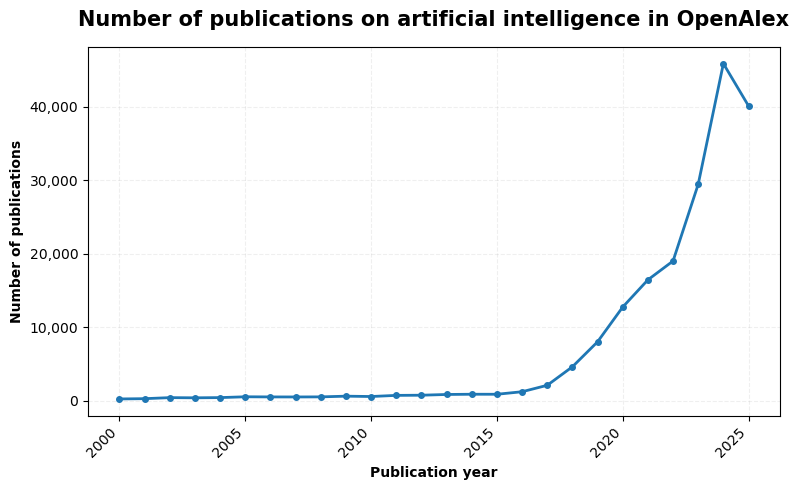

In [210]:
#plot results
from matplotlib.ticker import FuncFormatter, MaxNLocator, MultipleLocator

plt.figure(figsize=(8,5))
plt.plot(ai_trend_table['Year'],
          ai_trend_table['Number of AI works published'],
          marker = "o",
          linewidth = 2, 
          markersize = 4)

plt.title("Number of publications on artificial intelligence in OpenAlex",
          loc= 'center',
          fontsize = 15, 
          fontweight = 'bold',
          pad = 15)
plt.xlabel("Publication year",
           fontweight = 'bold')
plt.ylabel("Number of publications",
           fontweight = 'bold')

plt.xticks(rotation=45, ha="right")
plt.grid(True, linestyle="--", alpha=0.2)


ax = plt.gca()
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(x):,}")) # Display y axis numbers properly
ax.xaxis.set_major_locator(MultipleLocator(5))

plt.tight_layout()
plt.show

<b><i> Comments </b></i>

* Number of publications remain relatively low/flat through 2000s, then accelerates sharply after 2017

* Post-2020, the curve is nearly exponential in growth, aligning with generative-AI wave and broader cross-disciplinary adoption

* 2025 is likely low due to partial-year/indexing effect. It'll likely grow as more publications are added to OpenAlex

#### <i> <b> Part 2: How is this growth in 'artificial intelligence' research compared to other similar fields?

In this section, I'll compare how number of publications in related fields (e.g., LLMs) compare to number of publications on artificial intelligence. Specifically, I'll use three terms to compare against:

* 'GPT'

* 'large language model' 

* 'deep learning'

<b><i> Approach for analysis </b>

* In Part 1, I pulled count of all publications with the word 'artificial intelligence' grouped by year

* This worked quite easily since I only had one key term to search for

* Now, since I need to search for multiple terms and then save each of these search results as a table, I'm going to use a <i> for </i> loop to reduce the length of code



<b><i> Build helper functions </b>

In [178]:
#a set of keywords to search for
keywords = ["artificial intelligence", "GPT", "LLM", "deep learning"]

#helper filter function to use inside for loop
def build_filter(kw):
    phrase = str(kw).strip().replace('"', '\\"')   # escape any quotes
    return f'title.search:"{phrase}",from_publication_date:2000-01-01'

#testing that the function works in a simple for loop
for word in keywords:
    print(build_filter(word))


title.search:"artificial intelligence",from_publication_date:2000-01-01
title.search:"GPT",from_publication_date:2000-01-01
title.search:"LLM",from_publication_date:2000-01-01
title.search:"deep learning",from_publication_date:2000-01-01


<b><i> Define parameters + extract data using API + build dataframes </b>

In [182]:
#for loop to get count of publications for each key word

dfs = {}

for word in keywords:
    search_paramaters = {
        #filter for 'word' in title
        "filter":build_filter(word), 
        "group_by": "publication_year",
        "sort": "key:asc",
        "per_page": 200 
    }

    #call on API
    search_results = requests.get(url, search_paramaters)
    search_results.raise_for_status() #safety measure to notify errors
    search_data = search_results.json()

    #unique column name for each keyword
    colname = word


    #build dataframe
    df = (pd.DataFrame(search_data["group_by"])
            .rename(columns={"key":"Year", "count":"n_works"})
            .astype({"Year":"int","n_works":"int"})
            .sort_values("Year", ascending=True)
            .drop('key_display_name', axis=1)    
            .rename(columns={"n_works":colname})       
            )

    dfs[word] = df


In [183]:
#separate out dataframes
AI_df = dfs["artificial intelligence"]
GPT_df = dfs["GPT"]
deeplearning_df = dfs["deep learning"]
LLM_df = dfs["LLM"]

#check if every year exists for each dataframe
print(len(AI_df))
print(len(deeplearning_df))
print(len(GPT_df))
print(len(LLM_df))


26
26
26
26


<b> Build frequency table that compares # of publications for each keyword  </b>

In [187]:
#merge dataframes to create frequency table

publication_freq = (AI_df
                    .merge(GPT_df, on = "Year", how = "outer")
                    .merge(deeplearning_df, on = "Year", how = "outer")
                    .merge(LLM_df, on = "Year", how = "outer")
                    .sort_values("Year")
                    .rename(columns={"artificial intelligence":"AI","deep learning":"Deep Learning"}))

publication_freq.head(10).style

,Year,AI,GPT,Deep Learning,LLM
0,2000,277,31,7,2
1,2001,315,12,10,5
2,2002,456,20,11,4
3,2003,431,26,15,4
4,2004,461,21,13,10
5,2005,572,32,29,9
6,2006,553,36,27,8
7,2007,548,23,22,14
8,2008,559,33,30,11
9,2009,655,41,43,14


<b> Analyze results visually  </b>

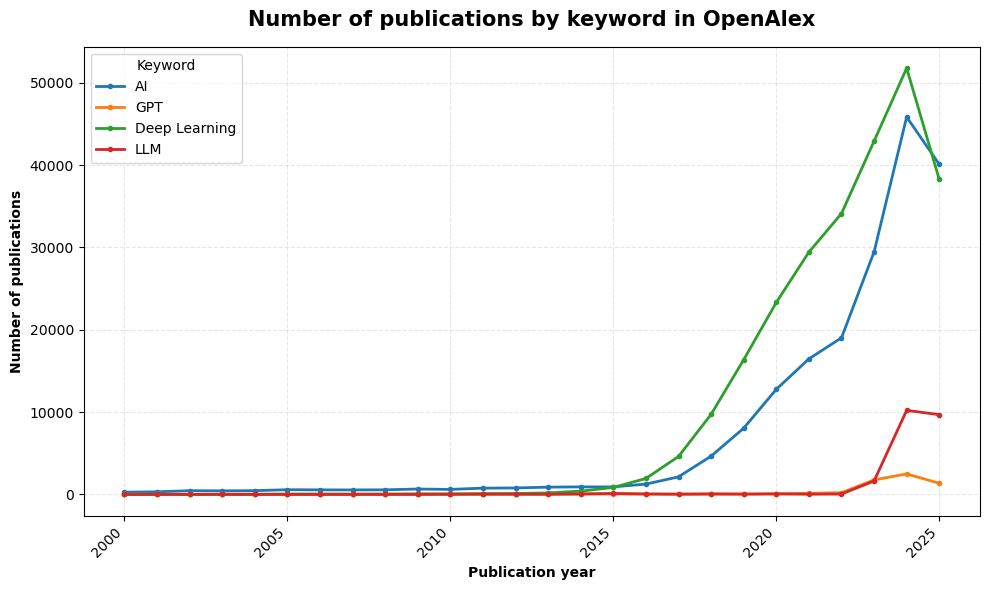

In [202]:
#plot data to compare results visually

plt.figure(figsize=(10, 6))

for col in ["AI", "GPT", "Deep Learning", "LLM"]:
    plt.plot(publication_freq["Year"], publication_freq[col], marker="o", linewidth=2, markersize=3, label=col)

plt.title("Number of publications by keyword in OpenAlex",loc= 'center',
          fontsize = 15, 
          fontweight = 'bold',
          pad = 15)
plt.xlabel("Publication year", fontweight = 'bold')
plt.ylabel("Number of publications", fontweight = 'bold')
plt.xticks(rotation=45, ha="right")
plt.legend(title="Keyword", ncol=1, frameon=True)
plt.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()



<b><i> Comments: </b> </i>

* Publications using the term 'deep learning' and 'artificial intelligence' in its titles have grown significantly in the last decade

* Deep learning surprisingly has similar or if not more number of open source publications compared to 'artificial intelligence'

* LLM and GPT have comparatively lower number of publications

* However, this could be because I only used the abbreviation to search for the keyword in the title of the papers. Next time, I could try to look for the full-form and the abbreviation in both the title and the abstract of the paper to ensure all publications are captured in our results